In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

from rich.progress import Progress

from pymc_extras.inference.advi.autoguide import AutoDiagonalNormal
from pymc_extras.inference.advi.training import compile_svi_training_fn

In [2]:
with pm.Model() as m:
    X = pm.Normal("X", 0, 1, size=(100, 3))
    alpha = pm.Normal("alpha", 0, 10)
    beta = pm.Normal("beta", 0, 5, size=(3,))

    mu = alpha + X @ beta
    sigma = pm.HalfNormal("sigma", 1)
    y = pm.Normal("y", mu=mu, sigma=sigma)

    prior = pm.sample_prior_predictive(random_seed=38)

Sampling: [X, alpha, beta, sigma, y]


In [3]:
draw = 123
true_params = {}
true_params["alpha"] = prior.prior.alpha.sel(chain=0, draw=draw).values
true_params["beta"] = prior.prior.beta.sel(chain=0, draw=draw).values
true_params["sigma"] = prior.prior.sigma.sel(chain=0, draw=draw).values

X_data = prior.prior.X.sel(chain=0, draw=draw).values
y_data = prior.prior.y.sel(chain=0, draw=draw).values

In [4]:
true_params

{'alpha': array(11.82213038),
 'beta': array([-0.92518728,  0.27270752, -0.20081106]),
 'sigma': array(0.40007044)}

In [5]:
m_obs = pm.observe(pm.do(m, {X: X_data}), {"y": y_data})

In [6]:
with m_obs:
    idata = pm.sample(mp_ctx="spawn")

NUTS[nutpie]: [sigma, beta, alpha]


Output()

In [7]:
guide = AutoDiagonalNormal(m_obs)

In [8]:
guide.params_init_values

{sigma_loc: array(0.27392337),
 sigma_scale: array(0.1),
 beta_loc: array([ 0.27392337, -0.46042657, -0.91805295]),
 beta_scale: array([0.1, 0.1, 0.1]),
 alpha_loc: array(0.27392337),
 alpha_scale: array(0.1)}

In [9]:
true_loc_dict = {k.name: v for k, v in guide.params_init_values.items()}
for key, value in true_params.items():
    true_loc_dict[f"{key}_loc"] = value
true_loc_dict

{'sigma_loc': array(0.40007044),
 'sigma_scale': array(0.1),
 'beta_loc': array([-0.92518728,  0.27270752, -0.20081106]),
 'beta_scale': array([0.1, 0.1, 0.1]),
 'alpha_loc': array(11.82213038),
 'alpha_scale': array(0.1)}

In [10]:
f_loss_dloss = compile_svi_training_fn(m_obs, guide, stick_the_landing=True)

In [11]:
f_loss_dloss(np.array(500), **true_loc_dict)

[array(292.28327897),
 array(-192.40376054),
 array(225.71245621),
 array([-16.45997256,   6.20412549,   1.81121387]),
 array([54.56682655, 46.10291533, 50.19731263]),
 array(10.29664017),
 array(46.12172872)]

In [12]:
init_param_values = {k.name: v for k, v in guide.params_init_values.items()}
opt_param_values = list(init_param_values.values())
learning_rate = 1e-5
n_iter = 2_000
loss_history = np.empty(n_iter)
draws = np.array(500, dtype=int)
with Progress() as progress:
    task = progress.add_task("Training", total=n_iter)
    for i in range(n_iter):
        loss, *grads = f_loss_dloss(draws, *opt_param_values)
        loss_history[i] = loss
        opt_param_values = [
            np.asarray(value - learning_rate * grad) for value, grad in zip(opt_param_values, grads)
        ]
        if i % 50 == 0:
            progress.update(task, description=f"Loss: {loss:.2f}")
        if i % 5_000 == 0 and i > 0:
            learning_rate = max(learning_rate / 5, 1e-5)
        progress.advance(task)

optimized_params = dict(zip(init_param_values, opt_param_values))

Output()

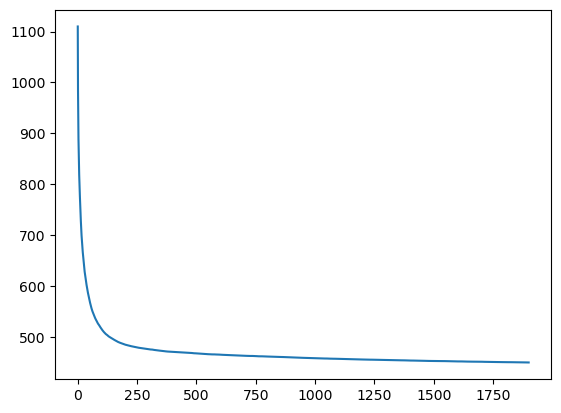

In [13]:
window_size = 100
kernel = np.full(window_size, 1 / window_size)
plt.plot(np.convolve(loss_history, kernel, mode="valid"))

In [14]:
n_iter = 2_000
loss_history = np.empty(n_iter)
draws = np.array(500, dtype=int)
learning_rate = 1e-3
with Progress() as progress:
    task = progress.add_task("Training", total=n_iter)
    for i in range(n_iter):
        loss, *grads = f_loss_dloss(draws, *opt_param_values)
        loss_history[i] = loss
        if any(np.isnan(d_loss).any() for d_loss in grads):
            print("Got nan, getting out")
            break
        opt_param_values = [
            np.asarray(value - learning_rate * grad) for value, grad in zip(opt_param_values, grads)
        ]

        if i % 50 == 0:
            progress.update(task, description=f"Loss: {loss:.3f}")
        progress.advance(task)

optimized_params = dict(zip(init_param_values, opt_param_values))
optimized_params

Output()

{'sigma_loc': array(-1.06361815),
 'sigma_scale': array(-2.60965289),
 'beta_loc': array([-0.90706437,  0.27188811, -0.15999071]),
 'beta_scale': array([-3.2978781 , -3.31300806, -3.19970805]),
 'alpha_loc': array(11.7805874),
 'alpha_scale': array(-3.31235872)}

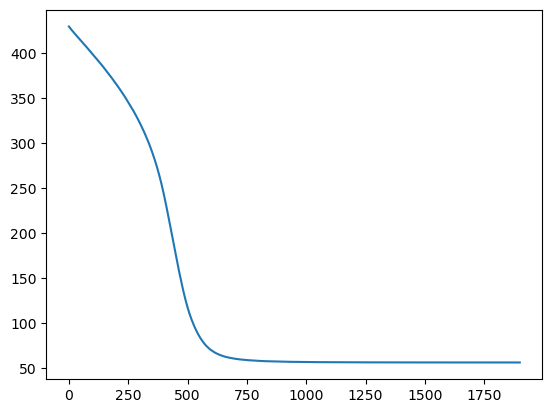

In [15]:
window_size = 100
kernel = np.full(window_size, 1 / window_size)
plt.plot(np.convolve(loss_history, kernel, mode="valid"))

In [16]:
true_params["beta"]

array([-0.92518728,  0.27270752, -0.20081106])

In [17]:
f_loss_dloss(np.array(500), **true_loc_dict)

[array(274.04016139),
 array(-156.3879545),
 array(214.98852293),
 array([-29.67677218,  -5.28190934, -14.6392089 ]),
 array([41.39547159, 38.52882102, 41.22487308]),
 array(19.2502576),
 array(49.03644364)]

In [18]:
f_loss_dloss(np.array(500, dtype=int), *opt_param_values)

[array(56.59073269),
 array(1.21062377),
 array(0.02572171),
 array([1.69474031, 1.19909813, 0.7318443 ]),
 array([0.08817787, 0.14385374, 0.01375097]),
 array(-1.03302889),
 array(0.04790749)]

In [19]:
def inverse_softplus(x):
    return np.log(np.expm1(x))


mcmc_param_values = {}
mcmc_param_values["sigma_loc"] = np.log(idata.posterior["sigma"]).mean(("chain", "draw")).values
mcmc_param_values["sigma_scale"] = inverse_softplus(
    np.log(idata.posterior["sigma"]).std(("chain", "draw"))
).values

for param in ("beta", "alpha"):
    mcmc_param_values[f"{param}_loc"] = idata.posterior[param].mean(("chain", "draw")).values
    mcmc_param_values[f"{param}_scale"] = inverse_softplus(
        idata.posterior[param].std(("chain", "draw"))
    ).values

In [20]:
optimized_params

{'sigma_loc': array(-1.06361815),
 'sigma_scale': array(-2.60965289),
 'beta_loc': array([-0.90706437,  0.27188811, -0.15999071]),
 'beta_scale': array([-3.2978781 , -3.31300806, -3.19970805]),
 'alpha_loc': array(11.7805874),
 'alpha_scale': array(-3.31235872)}

In [21]:
mcmc_param_values

{'sigma_loc': array(-1.06751448),
 'sigma_scale': array(-2.58842174),
 'beta_loc': array([-0.90951168,  0.27331875, -0.15955078]),
 'beta_scale': array([-3.31210977, -3.34718681, -3.21004855]),
 'alpha_loc': array(11.78100202),
 'alpha_scale': array(-3.31236803)}

In [22]:
f_loss_dloss(np.array(500, dtype=int), **mcmc_param_values)

[array(56.59453501),
 array(-1.43338846),
 array(0.06322469),
 array([-0.92101034,  0.03810468,  1.48909158]),
 array([0.00478187, 0.06316318, 0.03909179]),
 array(-0.08117211),
 array(0.12814448)]

## Todo:

- Does this "two models" frameworks fits into what we already have?
- rsample --> stochastic gradients? Or automatic reparameterization?
- figure out guide param initalization
- More flexible optimizers...